# **04. Time & Market Trend Analysis of Housing Market in Ames, Iowa**

## **Introduction :**


This analysis explores housing sales in Ames, Iowa, focusing on sales volume, price trends, and key factors affecting sale prices. We examine annual and monthly sales patterns, price per square foot, and the relationship between house age and sale price. Rolling averages and EMA are used to highlight underlying trends and seasonal patterns.


## **Goal:**

__1. Do sales volumes and prices vary with the seasons?__

__2. In what ways have housing prices in Ames shifted over time, considering both market shocks and the age of homes?__



| Metric | Formulation |
|---|---|
| Sales Volume | `COUNT(SalePrice)` |
| Average Sale Price | `AVG(SalePrice)` |
| Sale Price Per Square Foot | `SalePrice / GrLivArea` |


**About Dataset**

The data was collected by De Cock where 1460 properties were recorded in Ames, IA.

Brief description of columns will be used in analysis:

- **Id:** Property ID (unique identifier)
- **SalePrice:** Target variable — final selling price
- **GrLivArea:** Above-ground living area
- **YearBuilt:** Original Construction year
- **MoSold:** Month sold
- **YrSold:** Year sold

**This dataset represents the sale of properties in Ames, Iowa, where every single record represents a sale of individual house.
The house sales data spans from 2006 to 2010.**


In [2]:
import sys
sys.path.append('..')
from src.utilis import *

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose


In [3]:
# define path
parent_path = Path.cwd().parent
data_path = parent_path.joinpath("data", "raw")
processed_path = parent_path.joinpath("data", "processed")

org_files = []
display_md("**Original Files :**")
for file in data_path.rglob("*.csv"):
    org_files.append(file)
    print(org_files.index(file), " ", file.name)

pro_files = []
display_md("**Cleaned Files :**")
for fle in processed_path.rglob("*"):
    pro_files.append(fle)
    print(pro_files.index(fle), " ", fle.name)


**Original Files :**

0   sample_submission.csv
1   test.csv
2   train.csv


**Cleaned Files :**

0   .gitkeep
1   test_cleaned.csv
2   train_cleaned.csv


In [4]:
display_md("**Loading Original Datasets :**")

# Load original data 
train_org = load_data(org_files[2])
test_org = load_data(org_files[1])    

# standardize the column names
train_org.columns = train_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
test_org.columns = test_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

display_md("**Original Training and Testing data Shape**")

print("Original Training data shape: ", train_org.shape)
print("Original Testing data shape: ", test_org.shape)

display_md("**Duplicate Rows in  Data**")

print("Number of duplicate rows in training data: ", train_org.duplicated().sum())
print("Number of duplicate rows in testing data ", test_org.duplicated().sum())


**Loading Original Datasets :**

Data loaded successfully!
Data loaded successfully!


**Original Training and Testing data Shape**

Original Training data shape:  (1460, 81)
Original Testing data shape:  (1459, 80)


**Duplicate Rows in  Data**

Number of duplicate rows in training data:  0
Number of duplicate rows in testing data  0


In [5]:
# Selecting columns for analysis in this notebook and define new train and test datasets

df_train = train_org[['Id', 'GrLivArea', 'YearBuilt', 'MoSold', 'YrSold', 'SalePrice']].copy()
df_test = test_org[['Id', 'GrLivArea', 'YearBuilt', 'MoSold', 'YrSold']].copy()


#### **Columns Formatting and Consistency**

In [6]:
dtype_df = pd.DataFrame(index=df_train.columns, columns=['Dtype','nunique','unique', 'missing_value'])
dtype_df['Dtype'] = df_train.dtypes
dtype_df['nunique'] = df_train.nunique()
dtype_df['unique'] = [df_train[col].unique() for col in df_train.columns]
dtype_df['missing_value'] = [df_train[col].isnull().sum() for col in df_train.columns]
display(dtype_df)


,Dtype,nunique,unique,missing_value
Id,int64,1460,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0
GrLivArea,int64,861,"[1710, 1262, 1786, 1717, 2198, 1362, 1694, 209...",0
YearBuilt,int64,112,"[2003, 1976, 2001, 1915, 2000, 1993, 2004, 197...",0
MoSold,int64,12,"[2, 5, 9, 12, 10, 8, 11, 4, 1, 7, 3, 6]",0
YrSold,int64,5,"[2008, 2007, 2006, 2009, 2010]",0
SalePrice,int64,663,"[208500, 181500, 223500, 140000, 250000, 14300...",0


### **Seasonal Analysis with Graphs**

Let's examine the questions highlighted in the goal section:


#### **`Question 1.` Do sales volumes and prices vary with the seasons?**

We examine whether house sales vary by season from 2006–2010 in Ames, Iowa. 

Sales volume is measured as the number of houses sold per year and per month. 

We aggregate sales by year and visualize the trends using bar charts.


##### **Sales Volume Analysis**

**Number of houses sold per year**
 

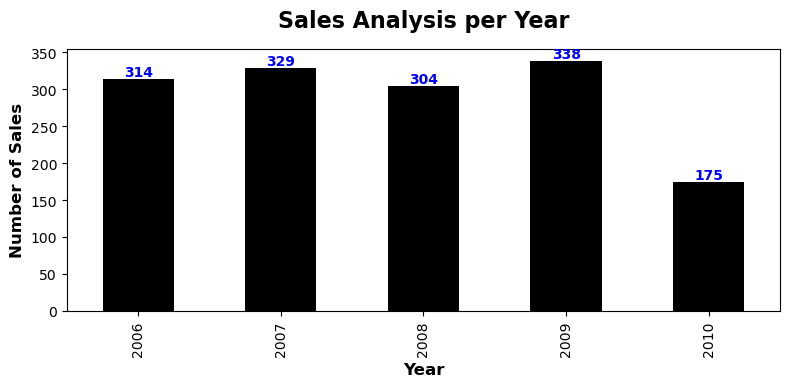

In [7]:
# house sales volume by year will consider feature `YrSold` and aggregate data on this
new_df = df_train.copy()

sales_volume = new_df.groupby(['YrSold']).size()

# Visualize by bar chart
sales_volume.plot(kind='bar', color="k", figsize=(8, 4))
# Annotate the text
for i, v in enumerate(sales_volume):
    plt.text(i, v, f"{v}", va='bottom', ha='center', fontsize=10, fontweight='bold', color='b')


plt.title("Sales Analysis per Year", fontsize=16, fontweight='bold', y=1.05)
plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Number of Sales", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


**Number of houses sold per month across year**

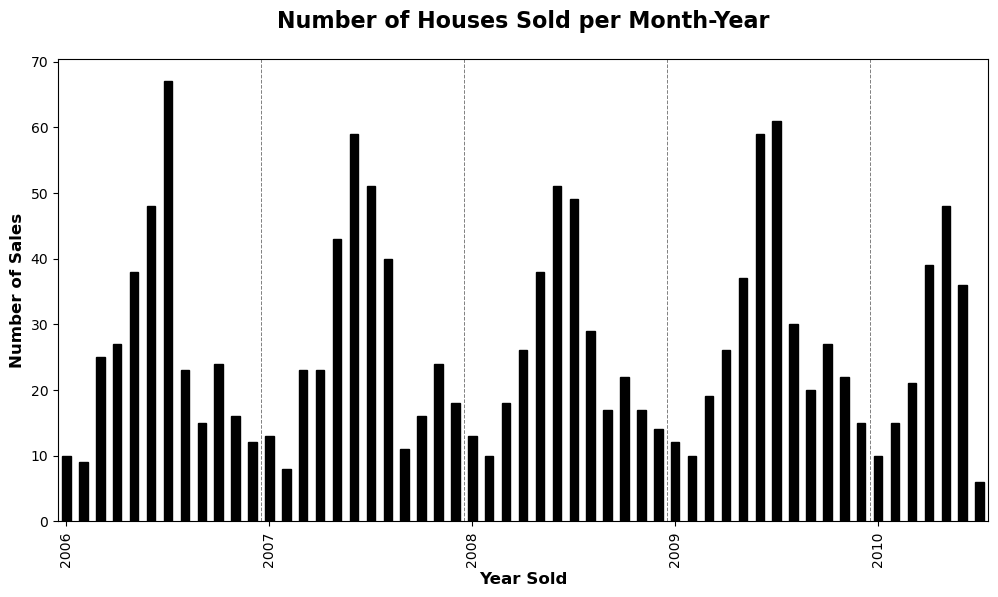

In [9]:
# Create proper datetime column
new_df['YearMonth'] = pd.to_datetime(
    new_df['YrSold'].map(str) + '-' + new_df['MoSold'].map(str),
    format='%Y-%m'
)

# Count sales per Year-Month
sales_counts = new_df.groupby('YearMonth').size().sort_index()

# Plot bar chart
fig, ax = plt.subplots(figsize=(12, 6))
sales_counts.plot(kind='bar', color='k', edgecolor='k', ax=ax)

# Replace x-axis ticks with years only
years = sales_counts.index.year.unique().sort_values().tolist()
year_positions = [sales_counts.index.get_loc(sales_counts.index[sales_counts.index.year == y][0]) for y in years]

ax.set_xticks(year_positions)
ax.set_xticklabels(years)

# Add vertical lines to separate years
for pos in year_positions:
    ax.axvline(pos-0.5, color='gray', linestyle='--', linewidth=0.7)

plt.title("Number of Houses Sold per Month-Year", fontsize=16, fontweight='bold', y=1.05)
plt.xlabel("Year Sold", fontsize=12, fontweight='bold')
plt.ylabel("Number of Sales", fontsize=12, fontweight='bold')
plt.show()


| **Sales Volume Analysis** | **Observation** |
|---|---|
| Annual Sales volume from 2006–2010 | Sales remained fairly consistent from 2006 to 2009, followed by a drop in 2010. |
| Monthly Sales volume across years | June and July recorded the highest sales each year, indicating a clear summer peak. |
| 2010 sales decline | The decline is because the dataset only includes sales through July 2010; the remaining months are unavailable. |


After examining annual sales seasonality, we use time series analysis to confirm the pattern by plotting monthly sales volume and its exponential moving average (EMA) over time.


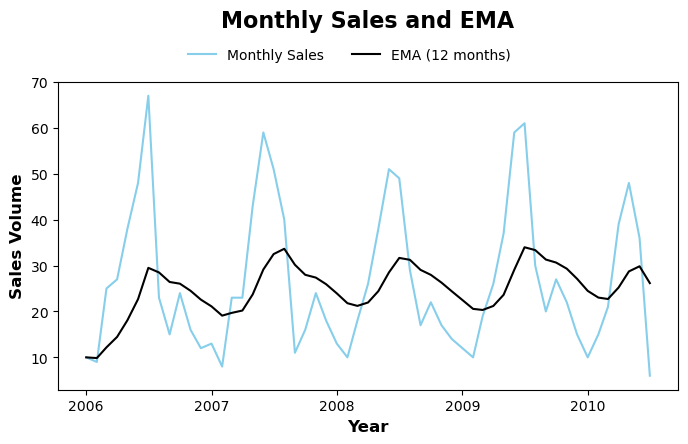

**Insight :** The chart shows monthly number of houses sale in sky blue and the EMA in black. Sales consistently peak around summer and decline afterward, confirming a clear seasonal pattern. This supports the earlier time-series analysis that higher summer demand may contribute to higher prices.

In [10]:
import matplotlib.dates as mdates

# plot line chart of volume per month over time
monthly_sales = sales_counts.reset_index(name='Count')

# compute exponential moving average(EMA)
monthly_sales['EMA'] = monthly_sales['Count'].ewm(span=12, adjust=False).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly_sales['YearMonth'], monthly_sales['Count'], color='skyblue', label="Monthly Sales")
ax.plot(monthly_sales['YearMonth'], monthly_sales['EMA'], color='k', label='EMA (12 months)')

# Force x-axis ticks to show only years
ax.xaxis.set_major_locator(mdates.YearLocator())          # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as YYYY

ax.set_title("Monthly Sales and EMA", fontsize=16, fontweight='bold', y=1.15)
ax.set_xlabel("Year", fontsize=12, fontweight='bold')
ax.set_ylabel("Sales Volume", fontsize=12, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(0.75, 1.15), ncol=2, frameon=False)

plt.show()

display_md("**Insight :** The chart shows monthly number of houses sale in sky blue and the EMA in black. Sales consistently peak around summer and decline afterward, confirming a clear seasonal pattern. This supports the earlier time-series analysis that higher summer demand may contribute to higher prices.")



**House Prices Trend Over Time**

Next, we examine how prices have changed over time.

**Monthly Price Trend**:
We plot the average monthly sale price, with blue showing the raw series and black showing the 12-month EMA to highlight the overall price trend.


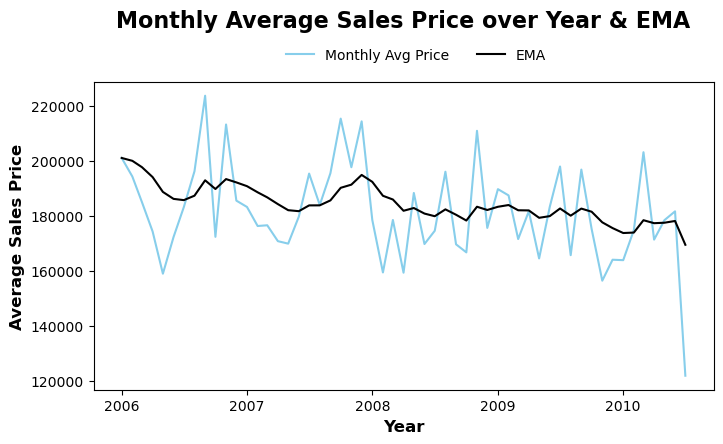

**Price Trend Observation :** Prices show a gradual decline with regular fluctuations, while the EMA smooths out these short‑term swings, highlights the overall trend clearer. Price peaks also align with the earlier sales-volume chart. To examine this pattern further, we'll use seasonal decomposition of monthly prices and compare it with sales volume time series.

In [11]:
# Compute aggregate sale price of house per month over years and EMA (exponential moving average)
avg_saleprice = new_df.groupby(['YearMonth'])['SalePrice'].mean().sort_index().reset_index(name='Avg_saleprice')
avg_saleprice['EMA'] = avg_saleprice['Avg_saleprice'].ewm(span=12, adjust=False).mean()
avg_saleprice.head()

# Plot via line chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(avg_saleprice['YearMonth'], avg_saleprice['Avg_saleprice'], color='skyblue', label="Monthly Avg Price")
ax.plot(avg_saleprice['YearMonth'], avg_saleprice['EMA'], color='k', label='EMA')

# Force x-axis ticks to show only years
ax.xaxis.set_major_locator(mdates.YearLocator())          # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as YYYY

ax.set_title("Monthly Average Sales Price over Year & EMA", fontsize=16, fontweight='bold', y=1.15)
ax.set_xlabel("Year", fontsize=12, fontweight='bold')
ax.set_ylabel("Average Sales Price", fontsize=12, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(0.75, 1.15), ncol=2, frameon=False)

plt.show()

display_md("**Price Trend Observation :** Prices show a gradual decline with regular fluctuations, while the EMA smooths out these short‑term swings, highlights the overall trend clearer. Price peaks also align with the earlier sales-volume chart. To examine this pattern further, we'll use seasonal decomposition of monthly prices and compare it with sales volume time series.")



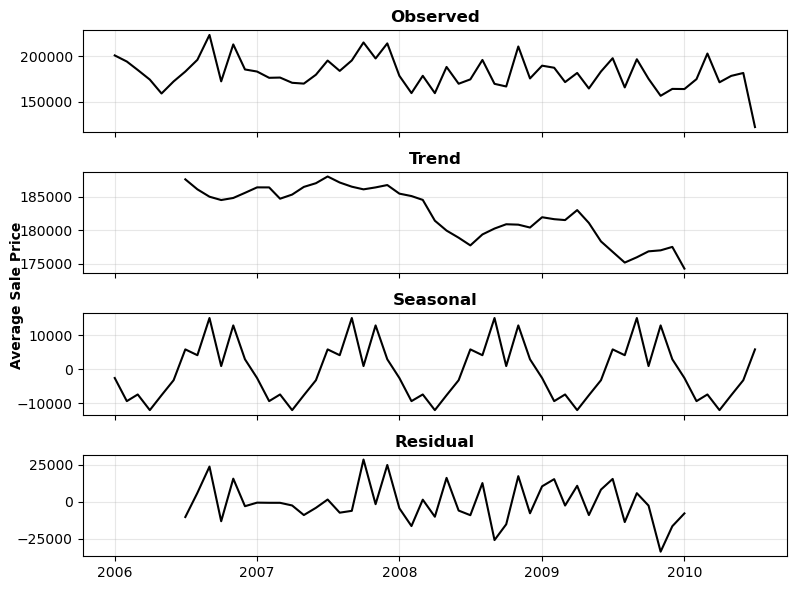

**Seasonal Price Analysis Observation :** The observed plot shows the raw time series, while the trend plot highlights the gradual decline in average prices we saw earlier. The seasonal plot clearly shows recurring peaks that match the sales volume series, likely reflecting higher demand in summer when people prefer to move, which can push prices up. The irregular component shows no strong additional pattern and looks quite similar to the raw series

Overall, prices tend to be higher in summer and lower in winter, indicating a seasonal relationship between timing, sales activity, and prices. 
This shows that timing the housing market can benefit both buyers and sellers. 
In Ames, buyers tend to find lower prices in winter, while sellers can often secure higher prices during the summer.


In [15]:
# To plot seasonal decomposition of monthly avg prices we will select YearMonth anf Avg_saleprice from avg_saleprice dataset 
monthly_sales = avg_saleprice[['YearMonth', 'Avg_saleprice']]

# Set datetime as index
monthly_sales = monthly_sales.set_index(['YearMonth'])

# Step 4: Seasonal decomposition (monthly frequency = 12)
decomposition = seasonal_decompose(monthly_sales['Avg_saleprice'], model='additive', period=12)

# Step 5: Plot decomposition
fig, ax = plt.subplots(4, 1, figsize=(8, 6), sharex=True)

ax[0].plot(decomposition.observed, color='k')
ax[0].set_title("Observed", fontweight='bold')
ax[0].grid(True, alpha=0.3)

ax[1].plot(decomposition.trend, color='k')
ax[1].set_title("Trend", fontweight='bold')
ax[1].grid(True, alpha=0.3)


ax[2].plot(decomposition.seasonal, color='k')
ax[2].set_title("Seasonal", fontweight='bold')
ax[2].grid(True, alpha=0.3)


ax[3].plot(decomposition.resid, color='k')
ax[3].set_title("Residual", fontweight='bold')
ax[3].grid(True, alpha=0.3)


fig.text(0.01, 0.5, "Average Sale Price", fontsize=10, fontweight='bold', va='center', rotation='vertical')

# Force x-axis ticks to show only years 
ax[3].xaxis.set_major_locator(mdates.YearLocator())          # one tick per year
ax[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as YYYY

plt.tight_layout()
plt.show()

display_md("**Seasonal Price Analysis Observation :** The observed plot shows the raw time series, while the trend plot highlights the gradual decline in average prices we saw earlier. The seasonal plot clearly shows recurring peaks that match the sales volume series, likely reflecting higher demand in summer when people prefer to move, which can push prices up. The irregular component shows no strong additional pattern and looks quite similar to the raw series")
print("Overall, prices tend to be higher in summer and lower in winter, indicating a seasonal relationship between timing, sales activity, and prices. \nThis shows that timing the housing market can benefit both buyers and sellers. \nIn Ames, buyers tend to find lower prices in winter, while sellers can often secure higher prices during the summer.")



---
#### __`Question 2.` In what ways have housing prices in Ames shifted over time, considering both market shocks and the age of homes?__

Our focus is on how the housing market turbulence between 2006 and 2010 influenced home sales in Ames, Iowa. Was the city shielded from these shocks, or did prices fall noticeably after 2007? 

Our goal is to see how average sale prices in Ames varied over time depending on when homes were sold. 

Using **sale price per square foot** to adjust for differences in house size and a 6‑month rolling average is applied to track price trends over time. 



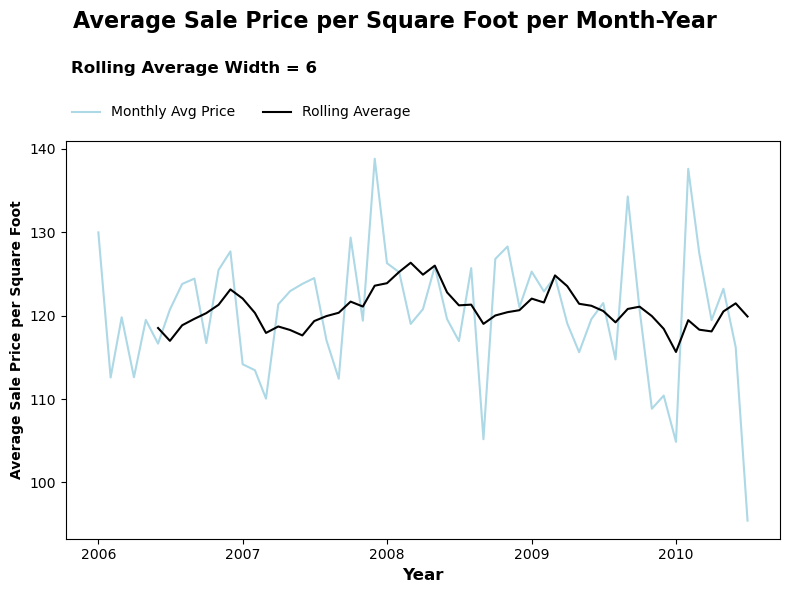

In [17]:
# Compute sale price per square foot
new_df['PricePerSF'] = new_df['SalePrice']/ new_df['GrLivArea']

# Compute avg price per sq. ft. per month-year 
avg_pricepersf = new_df.groupby(['YearMonth'])['PricePerSF'].mean().sort_index().reset_index(name='avg_sqft')
avg_pricepersf.head()

# Compute 6-month moving average
avg_pricepersf['Moving_avg'] = avg_pricepersf['avg_sqft'].rolling(window=6).mean()

# plotting
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(avg_pricepersf['YearMonth'], avg_pricepersf['avg_sqft'], color='lightblue', label="Monthly Avg Price")
ax.plot(avg_pricepersf['YearMonth'], avg_pricepersf['Moving_avg'], color='k', label='Rolling Average')

# Force x-axis ticks to show only years
ax.xaxis.set_major_locator(mdates.YearLocator())          # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # format as YYYY

fig.suptitle("Average Sale Price per Square Foot per Month-Year", fontsize=16, fontweight='bold')
ax.set_title("Rolling Average Width = 6", fontsize=12, fontweight='bold', x=0.18, y=1.15)
ax.set_xlabel("Year", fontsize=12, fontweight='bold')
ax.set_ylabel("Average Sale Price per Square Foot", fontsize=10, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)

plt.tight_layout()
plt.show()


The results show some fluctuations but overall a mild downward trend between 2006 and 2010. This indicates that Ames was affected by the 2008 recession, though less severely than the broader housing market. That relative stability allows us to draw broader insights without being overly concerned about nationwide housing inflation or deflation during that period.

**House age & Sale price :**
Since house sales show little variation across years and prices don't appear to depend much on the timing of the sale, we turn to examining whether a home's age and level of modernization influence its selling price.
Next, we explore how the sale price per square foot relates to the year a house was built, to see whether newer homes command higher prices. Simply relying on construction year isn't ideal, since many houses are remodeled or modernized over time. Instead, we use the year of the most recent remodel—or the build year if no remodel occurred—as a better measure. 

We examine the relationship between sale price per square foot and a home’s age to see whether newer or recently remodeled homes command higher prices. Since homes may be renovated over time, we use the most recent remodel year, or the original build year if never remodeled.


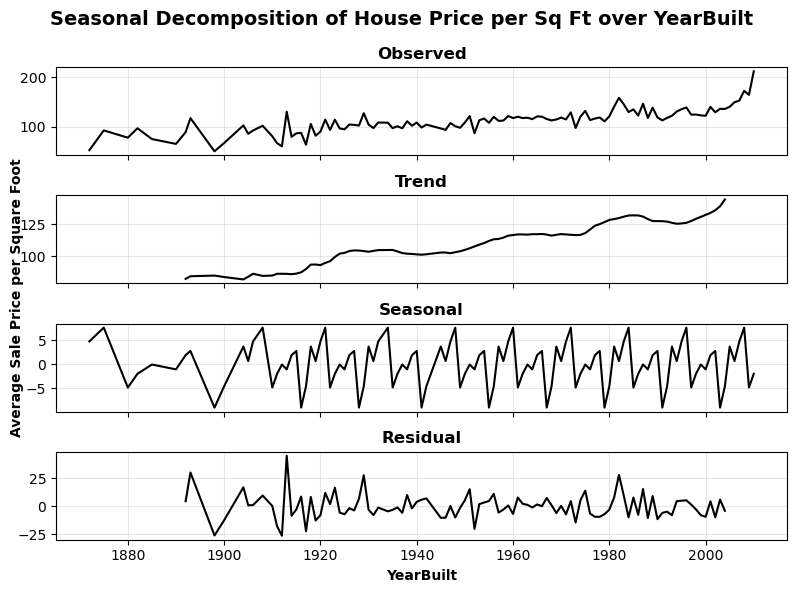

The seasonal decomposition plot reveals a clear upward trend, showing that more recently built or remodeled homes tend to sell for higher prices. The third plot, representing seasonality component, highlights fluctuations with peaks and valleys, likely reflecting natural cycles in the housing market.

In [19]:
# selecting features : PricePerSF and YearBuilt for analysis
seasonal_df = new_df[['YearBuilt', 'PricePerSF']].copy()

avg_pricesf = seasonal_df.groupby(['YearBuilt'])['PricePerSF'].mean().sort_index().reset_index(name='Avg_sqft')
# set datetime as index
avg_pricesf = avg_pricesf.set_index(['YearBuilt']).sort_index()

# Step 4: Seasonal decomposition (monthly frequency = 12)
decomposition = seasonal_decompose(avg_pricesf['Avg_sqft'], model='additive', period=12)

# Step 5: Plot decomposition
fig, ax = plt.subplots(4, 1, figsize=(8, 6), sharex=True)

ax[0].plot(decomposition.observed, color='k')
ax[0].set_title("Observed", fontweight='bold')
ax[0].grid(True, alpha=0.3)

ax[1].plot(decomposition.trend, color='k')
ax[1].set_title("Trend", fontweight='bold')
ax[1].grid(True, alpha=0.3)


ax[2].plot(decomposition.seasonal, color='k')
ax[2].set_title("Seasonal", fontweight='bold')
ax[2].grid(True, alpha=0.3)


ax[3].plot(decomposition.resid, color='k')
ax[3].set_title("Residual", fontweight='bold')
ax[3].grid(True, alpha=0.3)


fig.text(0.01, 0.5, "Average Sale Price per Square Foot", fontsize=10, fontweight='bold', va='center', rotation='vertical')

fig.suptitle("Seasonal Decomposition of House Price per Sq Ft over YearBuilt", fontsize=14, fontweight='bold')

ax[3].set_xlabel("YearBuilt", fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

display_md("The seasonal decomposition plot reveals a clear upward trend, showing that more recently built or remodeled homes tend to sell for higher prices. The third plot, representing seasonality component, highlights fluctuations with peaks and valleys, likely reflecting natural cycles in the housing market.")



---
## **Conclusion**

First, we look at seasonal trend in sales volume and price and concluded that both home sales volume and prices show seasonal patterns, with certain times of the year bringing more activity and noticeable price changes.

Second, we explored the impact of market shocks revealed a modest effect of the 2008 recession on housing prices in Ames and the seasonal decomposition showing that more recently built or remodeled homes tend to sell for higher prices.